## Run locally - news data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def wrangle(path):
    # Load data
    df = pd.read_csv(path)

    # Convert 'date' column to datetime
    df['date'] = pd.to_datetime(df['date'])

    # Sort data
    df = df.sort_values(by='date', ascending=True) 

    # Round up to the next hour
    df['date'] = df['date'].dt.ceil('h')

    # Drop columns
    df = df.drop(columns=['title', 'article_text'])

    # Set index
    df.set_index('date', inplace=True)

    return df

In [3]:
df = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/bitcoin_news_data.csv")

In [4]:
df.head()

,url,sentiment_labels,sentiment_confidence,sentiment_prob_class_0,sentiment_prob_class_1,sentiment_prob_class_2
date,,,,,,
2011-06-22 11:00:00,https://finance.yahoo.com/news/2011-06-22-comp...,negative,0.998087,0.998087,0.001404,0.000509
2012-02-01 19:00:00,https://finance.yahoo.com/news/bitcoin-may-cur...,neutral,0.790765,0.000661,0.790765,0.208574
2012-03-22 20:00:00,https://finance.yahoo.com/news/africa-adopt-sh...,positive,0.994885,0.003541,0.001573,0.994885
2012-08-23 00:00:00,https://finance.yahoo.com/news/2012-08-22-mast...,neutral,0.999715,0.000199,0.999715,0.000085
2012-09-07 14:00:00,https://finance.yahoo.com/news/claim-romney-ta...,neutral,0.999659,0.000247,0.999659,0.000094


In [5]:
df.tail()

,url,sentiment_labels,sentiment_confidence,sentiment_prob_class_0,sentiment_prob_class_1,sentiment_prob_class_2
date,,,,,,
2024-01-24 14:00:00,https://finance.yahoo.com/news/fidelity-blackr...,positive,0.999162,0.000214,0.000624,0.999162
2024-01-24 14:00:00,https://finance.yahoo.com/news/most-liquid-spo...,neutral,0.976094,0.000965,0.976094,0.022941
2024-01-24 15:00:00,https://finance.yahoo.com/news/alameda-gap-kee...,negative,0.997453,0.997453,0.001367,0.001181
2024-01-24 21:00:00,https://finance.yahoo.com/news/cryptocurrency-...,positive,0.992705,0.001338,0.005957,0.992705
2024-01-24 22:00:00,https://finance.yahoo.com/news/china-rescue-bu...,positive,0.947974,0.051819,0.000208,0.947974


In [6]:
df.isna().sum()

url                       0
sentiment_labels          0
sentiment_confidence      0
sentiment_prob_class_0    0
sentiment_prob_class_1    0
sentiment_prob_class_2    0
dtype: int64

In [7]:
df.describe()

,sentiment_confidence,sentiment_prob_class_0,sentiment_prob_class_1,sentiment_prob_class_2
count,80806.000000,80806.000000,80806.000000,80806.000000
mean,0.956419,0.261948,0.221255,0.516797
std,0.101262,0.418342,0.387382,0.475641
min,0.336958,0.000041,0.000041,0.000041
25%,0.981103,0.000230,0.000322,0.001505
50%,0.997876,0.000632,0.001458,0.683237
75%,0.999440,0.680234,0.186061,0.999148
max,0.999893,0.998917,0.999893,0.999729


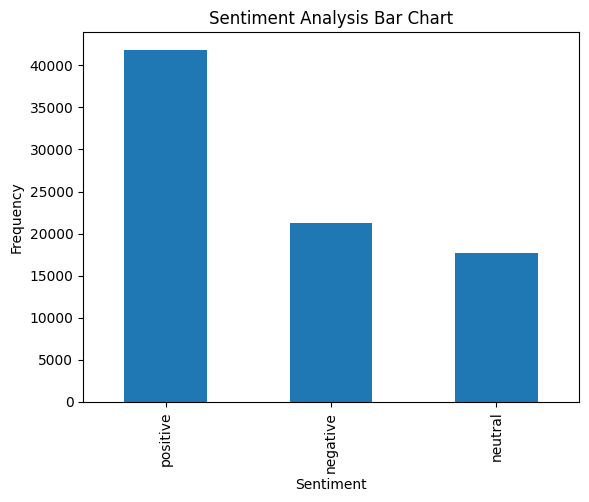

In [8]:
df['sentiment_labels'].value_counts().plot(kind='bar')
plt.title('Sentiment Analysis Bar Chart')
plt.xlabel('Sentiment')
plt.ylabel('Frequency');

### Create Sentiment Scores (Polarity) between -1 and 1 (averaging used)

In [9]:
# Given "class_2" is positive sentiment and "class_0" is negative sentiment

# Compute weighted sentiment score using probabilities
df['sentiment_score'] = df['sentiment_prob_class_2'] - df['sentiment_prob_class_0']

# Group by rounded-up hour, and create a new df with the mean sentiment score
df_score = df.groupby(df.index)['sentiment_score'].mean()

# Convert Series to DataFrame
df_score = df_score.to_frame()

# Display the cleaned DataFrame
df_score.head()

,sentiment_score
date,
2011-06-22 11:00:00,-0.997578
2012-02-01 19:00:00,0.207913
2012-03-22 20:00:00,0.991344
2012-08-23 00:00:00,-0.000114
2012-09-07 14:00:00,-0.000152


In [10]:
df_score.tail()

,sentiment_score
date,
2024-01-24 13:00:00,0.015544
2024-01-24 14:00:00,0.673418
2024-01-24 15:00:00,-0.996272
2024-01-24 21:00:00,0.991366
2024-01-24 22:00:00,0.896155


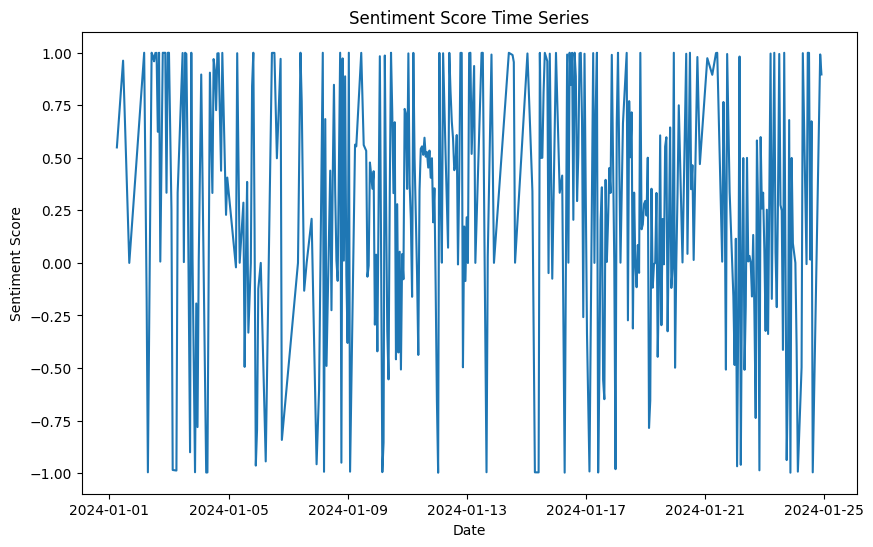

In [11]:
# Filter data for dates after 2024
df_filtered = df_score[df_score.index >= '2024-01-01']

# Plot sentiment scores
plt.figure(figsize=(10, 6))
plt.plot(df_filtered.index, df_filtered['sentiment_score'])
plt.title('Sentiment Score Time Series')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.show()

In [12]:
df_score.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/bitcoin_scores.csv")